In [ ]:
!nvidia-smi

In [ ]:
!pip install ultralytics

In [ ]:
import os
import shutil

# Automatically search for solution.py and copy it
found_solution = False
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'solution.py' in filenames:
        source_path = os.path.join(dirname, 'solution.py')
        shutil.copy(source_path, '/kaggle/working/solution.py')
        print(f"Success! Found and copied from: {source_path}")
        found_solution = True
        break

if not found_solution:
    print("Error: Could not find solution.py. Make sure it finished uploading to Kaggle!")

In [ ]:
import os
import json
from solution import detect_events

# Automatically find the first .mp4 video you uploaded
video_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.mp4'):
            video_path = os.path.join(dirname, filename)
            break
    if video_path:
        break

if video_path:
    print(f"Starting detection on {video_path}...")
    events = detect_events(video_path)

    print(f"\n--- DONE! Detected {len(events)} events ---")
    for event in events:
        print(f"Start: {event[0]:.2f}s | End: {event[1]:.2f}s | Type: {event[2]}")

    with open("predictions.json", "w") as f:
        json.dump(events, f, indent=2)
    print("\nSaved to predictions.json in your Kaggle output folder.")
else:
    print("Error: Could not find an .mp4 video file in your uploads.")

%%writefile solution.py

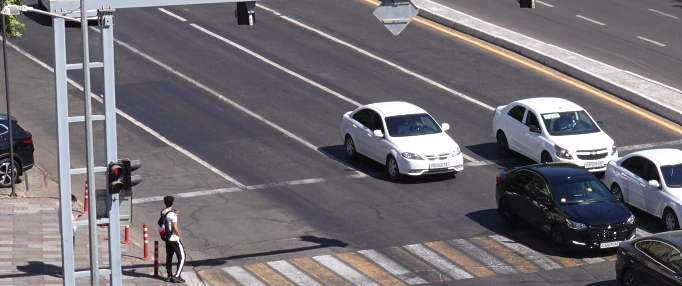

In [23]:
%%writefile solution.py

from __future__ import annotations

import cv2
import math
import numpy as np
from ultralytics import YOLO

CLASSES: list[str] = [
    "accident", "near_miss", "red_light", "wrong_way", "illegal_u_turn", 
    "stopped_vehicle", "jaywalking", "failure_to_yield", "illegal_turn", 
    "solid_line_crossing", "stop_line", "congestion", "road_obstacle", "fire_smoke"
]

RISK_HORIZON_SEC = 5.0

detector = YOLO("yolo11m.pt")

# --- SPATIAL ZONES ---
road_poly = np.array([
    [400, 850], [1700, 350], [3800, 350], [3800, 1800], 
    [1500, 2160], [400, 2160], [200, 1200]
], np.int32)

zebra_1 = np.array([[250, 950], [1600, 800], [1650, 1050], [250, 1250]], np.int32)
zebra_2 = np.array([[1550, 800], [3000, 700], [3000, 950], [1550, 1100]], np.int32)
zebra_3 = np.array([[0, 1300], [1200, 1100], [1800, 2160], [0, 2160]], np.int32)

queue_zone = np.array([[300, 250], [1500, 150], [1800, 450], [400, 850]], np.int32)
intersection_turn_zone = np.array([[1000, 450], [2200, 450], [2200, 1100], [1000, 1100]], np.int32)
bus_stop_zone = np.array([[1200, 200], [2500, 200], [2500, 450], [1200, 450]], np.int32)
parking_zone = np.array([[0, 800], [250, 800], [250, 1200], [0, 1200]], np.int32)
wrong_way_zone = np.array([[600, 250], [1700, 250], [1400, 400], [400, 400]], np.int32)

# Specific zones for intersection violations
stop_line_zone = np.array([[400, 800], [1550, 390], [1600, 420], [430, 830]], np.int32)
crosswalk_box = np.array([[430, 830], [1600, 420], [1700, 470], [550, 900]], np.int32)
junction_poly = np.array([[550, 880], [1650, 470], [2800, 900], [1500, 1600]], np.int32)

LEFT_LANE_LINE = (100, 250, 1600, 950)
PED_LIGHT_BOX = (530, 950, 580, 1050)

def detect_events(video_path: str) -> list[list]:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames_for_10_sec = int((fps / 5) * 10) 
    
    raw_events = []
    trajectories = {}
    initial_states = {}  
    active_stop_lines = {}  
    
    line_x1, line_y1, line_x2, line_y2 = LEFT_LANE_LINE
    lx1, ly1, lx2, ly2 = PED_LIGHT_BOX
    
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_idx += 1
        if frame_idx % 5 != 0:
            continue
            
        light_crop = frame[ly1:ly2, lx1:lx2]
        hsv_crop = cv2.cvtColor(light_crop, cv2.COLOR_BGR2HSV)
        
        mask_g = cv2.inRange(hsv_crop, np.array([40, 50, 50]), np.array([90, 255, 255]))
        green_pixels = cv2.countNonZero(mask_g)
        
        mask_r1 = cv2.inRange(hsv_crop, np.array([0, 70, 50]), np.array([10, 255, 255]))
        mask_r2 = cv2.inRange(hsv_crop, np.array([170, 70, 50]), np.array([180, 255, 255]))
        red_pixels = cv2.countNonZero(cv2.bitwise_or(mask_r1, mask_r2))
        
        vehicle_red_light = red_pixels > green_pixels and red_pixels > 10
            
        results = detector.track(frame, persist=True, conf=0.3, classes=[0, 2, 5, 7], verbose=False)
        
        peds_z1, peds_z2, peds_z3 = [], [], []
        vehs_z1, vehs_z2, vehs_z3 = [], [], []
        current_vehs_info = [] 
        
        zone_speeds = []
        timestamp = frame_idx / fps
        
        boxes_obj = results[0].boxes
        if boxes_obj is not None and boxes_obj.id is not None:
            boxes = boxes_obj.xyxy.cpu().numpy()
            track_ids = boxes_obj.id.int().cpu().numpy()
            class_ids = boxes_obj.cls.int().cpu().numpy()
            
            for box, track_id, cls_id in zip(boxes, track_ids, class_ids):
                cx = int((box[0] + box[2]) / 2)
                cy = int(box[3])
                
                history = trajectories.get(track_id, [])
                history.append((cx, cy))
                
                if len(history) > frames_for_10_sec:
                    history = history[-frames_for_10_sec:]
                trajectories[track_id] = history
                
                if len(history) >= 2:
                    old_cx, old_cy = history[-2]
                    
                    if cls_id in [2, 5, 7]:
                        current_vehs_info.append((track_id, box, cx, cy, history))
                        
                        if track_id not in initial_states and len(history) >= 5:
                            start_dx = history[-1][0] - history[0][0]
                            start_dy = history[-1][1] - history[0][1]
                            if math.hypot(start_dx, start_dy) > 15:
                                initial_states[track_id] = (history[0][0], history[0][1], start_dx, start_dy)
                        
                        # --- RED LIGHT & STOP LINE LOGIC ---
                        if vehicle_red_light:
                            
                            # 1. STOP LINE: Check if any part of the front footprint touches the line or crosswalk
                            bl = (int(box[0]), int(box[3]))
                            br = (int(box[2]), int(box[3]))
                            bc = (cx, cy)
                            
                            touching_line = any(cv2.pointPolygonTest(stop_line_zone, pt, False) >= 0 for pt in [bl, br, bc])
                            touching_crosswalk = any(cv2.pointPolygonTest(crosswalk_box, pt, False) >= 0 for pt in [bl, br, bc])
                            
                            if touching_line or touching_crosswalk:
                                if len(history) >= 10:
                                    past_cx, past_cy = history[-10]
                                    if math.hypot(cx - past_cx, cy - past_cy) < 30: 
                                        if track_id not in active_stop_lines:
                                            active_stop_lines[track_id] = [max(0.0, timestamp - 2.0), timestamp] 
                                        else:
                                            active_stop_lines[track_id][1] = timestamp 
                            
                            # 2. RED LIGHT: Strict momentum check, pushing timestamp backwards to entry moment
                            if cv2.pointPolygonTest(junction_poly, (cx, cy), False) >= 0:
                                if len(history) >= 10: 
                                    past_10_cx, past_10_cy = history[-10]
                                    was_in_queue = cv2.pointPolygonTest(queue_zone, (past_10_cx, past_10_cy), False) >= 0
                                    was_in_cross = cv2.pointPolygonTest(crosswalk_box, (past_10_cx, past_10_cy), False) >= 0
                                    
                                    if (was_in_queue or was_in_cross) and (cy - past_10_cy) > 50:
                                        raw_events.append([max(0.0, timestamp - 2.0), timestamp + 1.0, "red_light"])
                                        trajectories[track_id] = history[-5:] 
                        
                        # 3. FLUSH STOP LINE
                        if track_id in active_stop_lines:
                            is_moving = len(history) >= 10 and math.hypot(cx - history[-10][0], cy - history[-10][1]) >= 30
                            
                            if not vehicle_red_light or is_moving:
                                start_t, end_t = active_stop_lines[track_id]
                                if end_t - start_t >= 1.0:  
                                    raw_events.append([start_t, end_t, "stop_line"])
                                del active_stop_lines[track_id]
                        
                        is_in_queue = cv2.pointPolygonTest(queue_zone, (cx, cy), False) >= 0
                        is_in_inter = cv2.pointPolygonTest(junction_poly, (cx, cy), False) >= 0
                        if is_in_queue or is_in_inter:
                            if len(history) >= 10:
                                past_cx, past_cy = history[-10]
                                dist = math.hypot(cx - past_cx, cy - past_cy)
                                zone_speeds.append(dist / 10.0) 

                        if cv2.pointPolygonTest(wrong_way_zone, (cx, cy), False) >= 0:
                            if len(history) >= 15:
                                past_cx, past_cy = history[-15]
                                if (cx - past_cx > 40) or (cy - past_cy > 40):
                                    raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "wrong_way"])
                                    trajectories[track_id] = history[-5:] 
                            
                        dx = cx - old_cx
                        dy = cy - old_cy
                        if cv2.pointPolygonTest(zebra_1, (cx, cy), False) >= 0:
                            vehs_z1.append((cx, cy, dx, dy))
                        elif cv2.pointPolygonTest(zebra_2, (cx, cy), False) >= 0:
                            vehs_z2.append((cx, cy, dx, dy))
                        elif cv2.pointPolygonTest(zebra_3, (cx, cy), False) >= 0:
                            vehs_z3.append((cx, cy, dx, dy))
                            
                        if track_id in initial_states and len(history) >= 5:
                            start_cx, start_cy, start_dx, start_dy = initial_states[track_id]
                            
                            if cv2.pointPolygonTest(queue_zone, (start_cx, start_cy), False) >= 0:
                                end_dx = history[-1][0] - history[-5][0]
                                end_dy = history[-1][1] - history[-5][1]
                                
                                start_mag = math.hypot(start_dx, start_dy)
                                end_mag = math.hypot(end_dx, end_dy)
                                
                                if end_mag > 10:
                                    dot_prod = (start_dx * end_dx) + (start_dy * end_dy)
                                    cos_angle = dot_prod / (start_mag * end_mag)
                                    
                                    if cos_angle < -0.7:
                                        if cv2.pointPolygonTest(intersection_turn_zone, (cx, cy), False) >= 0:
                                            val = (start_cx - line_x1) * (line_y2 - line_y1) - (start_cy - line_y1) * (line_x2 - line_x1)
                                            if val < 0:
                                                raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "illegal_u_turn"])
                                                del initial_states[track_id] 

                        if len(history) >= frames_for_10_sec and not vehicle_red_light:
                            ten_sec_cx, ten_sec_cy = history[-frames_for_10_sec]
                            if math.hypot(cx - ten_sec_cx, cy - ten_sec_cy) < 20:
                                if cv2.pointPolygonTest(road_poly, (cx, cy), False) >= 0:
                                    in_queue = cv2.pointPolygonTest(queue_zone, (cx, cy), False) >= 0
                                    in_turn = cv2.pointPolygonTest(intersection_turn_zone, (cx, cy), False) >= 0
                                    in_bus_stop = cv2.pointPolygonTest(bus_stop_zone, (cx, cy), False) >= 0
                                    in_parking = cv2.pointPolygonTest(parking_zone, (cx, cy), False) >= 0
                                    
                                    if not (in_queue or in_turn or in_bus_stop or in_parking):
                                        raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "stopped_vehicle"])
                                        trajectories[track_id] = history[-(frames_for_10_sec - 5):]

                    elif cls_id == 0:
                        w = box[2] - box[0]
                        h = box[3] - box[1]
                        
                        # Geometric filter: Pedestrians are generally vertical.
                        # This filters out cars/shadows misclassified as pedestrians.
                        if h > (w * 0.8): 
                            dist_road = cv2.pointPolygonTest(road_poly, (cx, cy), True)
                            dist_z1 = cv2.pointPolygonTest(zebra_1, (cx, cy), True)
                            dist_z2 = cv2.pointPolygonTest(zebra_2, (cx, cy), True)
                            dist_z3 = cv2.pointPolygonTest(zebra_3, (cx, cy), True)
                            
                            is_firmly_on_road = dist_road > 60
                            is_outside_zebras = (dist_z1 < -80) and (dist_z2 < -80) and (dist_z3 < -80)
                            
                            if is_firmly_on_road and is_outside_zebras:
                                # Increased history requirement to prove it's a real, persistent object
                                if len(history) >= 20: 
                                    dist_walked = math.hypot(cx - history[-20][0], cy - history[-20][1])
                                    if 40 < dist_walked < 150:
                                        raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "jaywalking"])
                                        trajectories[track_id] = history[-5:] 
                            
                        if dist_z1 >= -20: peds_z1.append((cx, cy))
                        elif dist_z2 >= -20: peds_z2.append((cx, cy))
                        elif dist_z3 >= -20: peds_z3.append((cx, cy))

        avg_speed = sum(zone_speeds) / len(zone_speeds) if len(zone_speeds) >= 5 else 10.0
        
        # --- KINEMATIC ACCIDENT & NEAR MISS EVALUATION ---
        for i, veh1 in enumerate(current_vehs_info):
            t1, box1, cx1, cy1, hist1 = veh1
            
            if len(hist1) >= 15:
                dx1, dy1 = hist1[-5][0] - hist1[-15][0], hist1[-5][1] - hist1[-15][1]
                dx2, dy2 = hist1[-1][0] - hist1[-5][0], hist1[-1][1] - hist1[-5][1]
                s1 = math.hypot(dx1, dy1)
                s2 = math.hypot(dx2, dy2)
                
                is_near_miss = False
                if s1 > 5.0: 
                    if s2 < s1 * 0.2: 
                        is_near_miss = True
                    elif s2 > 10: 
                        cos_theta = (dx1*dx2 + dy1*dy2) / (s1 * s2 + 1e-5)
                        if cos_theta < 0.5: 
                            is_near_miss = True
                            
                if is_near_miss:
                    for j, veh2 in enumerate(current_vehs_info):
                        if i != j:
                            t2, box2, cx2, cy2, hist2 = veh2
                            overlap_box1_x = max(0, min(box1[2], box2[2]) - max(box1[0], box2[0]))
                            overlap_box1_y = max(0, min(box1[3], box2[3]) - max(box1[1], box2[1]))
                            has_overlap = (overlap_box1_x * overlap_box1_y) > 0
                            
                            if math.hypot(cx1 - cx2, cy1 - cy2) < 80 and not has_overlap:
                                raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "near_miss"])
                                trajectories[t1] = hist1[-5:]
                                break
                                
            for j in range(i + 1, len(current_vehs_info)):
                veh2 = current_vehs_info[j]
                t2, box2, cx2, cy2, hist2 = veh2
                
                if len(hist1) >= 10 and len(hist2) >= 10:
                    speed1 = math.hypot(hist1[-1][0] - hist1[-3][0], hist1[-1][1] - hist1[-3][1])
                    speed2 = math.hypot(hist2[-1][0] - hist2[-3][0], hist2[-1][1] - hist2[-3][1])
                    
                    if speed1 < 1.0 and speed2 < 1.0:
                        prior_speed1 = math.hypot(hist1[-5][0] - hist1[-10][0], hist1[-5][1] - hist1[-10][1])
                        prior_speed2 = math.hypot(hist2[-5][0] - hist2[-10][0], hist2[-5][1] - hist2[-10][1])
                        
                        high_approach = (prior_speed1 > 18.0) or (prior_speed2 > 18.0)
                        
                        if high_approach:
                            in_road = cv2.pointPolygonTest(road_poly, (cx1, cy1), False) >= 0
                            in_queue = cv2.pointPolygonTest(queue_zone, (cx1, cy1), False) >= 0
                            in_park = cv2.pointPolygonTest(parking_zone, (cx1, cy1), False) >= 0
                            
                            is_open_road_crash = in_road and not (in_queue or in_park)
                            is_queue_crash = in_queue and not vehicle_red_light and avg_speed >= 6.0
                            
                            if is_open_road_crash or is_queue_crash:
                                overlap_box1_x = max(0, min(box1[2], box2[2]) - max(box1[0], box2[0]))
                                overlap_box1_y = max(0, min(box1[3], box2[3]) - max(box1[1], box2[1]))
                                intersection_area = overlap_box1_x * overlap_box1_y
                                
                                area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
                                area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
                                smaller_area = min(area1, area2)
                                
                                if smaller_area > 0 and (intersection_area / smaller_area > 0.45):
                                    raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "accident"])
                                    trajectories[t1] = hist1[-5:]
                                    trajectories[t2] = hist2[-5:]

        if not vehicle_red_light and avg_speed < 6.0:  
            raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "congestion"])

        for vehs_z, peds_z in [(vehs_z1, peds_z1), (vehs_z2, peds_z2), (vehs_z3, peds_z3)]:
            for vx, vy, dx, dy in vehs_z:
                for px, py in peds_z:
                    if math.hypot(vx - px, vy - py) < 150 and math.hypot(dx, dy) > 5:
                        if (dx * (px - vx) + dy * (py - vy)) > 0:
                            raw_events.append([max(0.0, timestamp - 1.0), timestamp + 1.0, "failure_to_yield"])

    cap.release()
    
    for track_id, (start_t, end_t) in active_stop_lines.items():
        if end_t - start_t >= 1.0:
            raw_events.append([start_t, end_t, "stop_line"])
    
    merged_events = []
    grouped_events = {}
    for start, end, label in raw_events:
        grouped_events.setdefault(label, []).append([start, end])
        
    for label, intervals in grouped_events.items():
        intervals.sort(key=lambda x: x[0])
        merged = [intervals[0]]
        
        for current in intervals[1:]:
            prev = merged[-1]
            gap_threshold = 5.0 if label == "congestion" else 0.0
            
            if current[0] <= prev[1] + gap_threshold:
                prev[1] = max(prev[1], current[1])
            else:
                merged.append(current)
                
        for m in merged:
            merged_events.append([m[0], m[1], label])
            
    return merged_events

class RiskEstimator:
    def reset(self, meta: dict) -> None:
        self.meta = meta
        self.last_score = 0.0
        self.history = {} 
        self.RISK_HORIZON = 2.0  # Tightened to 2 seconds for immediate threats

    def step(self, frame: np.ndarray, t_sec: float) -> float:
        results = detector.track(frame, persist=True, conf=0.3, classes=[0, 2, 5, 7], verbose=False)
        
        current_objects = []
        boxes_obj = results[0].boxes
        
        if boxes_obj is not None and boxes_obj.id is not None:
            boxes = boxes_obj.xyxy.cpu().numpy()
            track_ids = boxes_obj.id.int().cpu().numpy()
            cls_ids = boxes_obj.cls.int().cpu().numpy()
            
            for box, tid, cid in zip(boxes, track_ids, cls_ids):
                cx = (box[0] + box[2]) / 2.0
                cy = (box[1] + box[3]) / 2.0
                
                hist = self.history.setdefault(tid, [])
                hist.append((t_sec, cx, cy))
                
                if len(hist) > 15: 
                    hist.pop(0)
                    
                vx, vy = 0.0, 0.0
                if len(hist) >= 5:
                    dt = hist[-1][0] - hist[0][0]
                    if dt > 0:
                        vx = (hist[-1][1] - hist[0][1]) / dt
                        vy = (hist[-1][2] - hist[0][2]) / dt
                        
                current_objects.append({
                    'id': tid, 'cls': cid, 
                    'cx': cx, 'cy': cy, 
                    'vx': vx, 'vy': vy,
                    'speed': math.hypot(vx, vy)
                })
        
        current_frame_risk = 0.0
        
        for i in range(len(current_objects)):
            for j in range(i + 1, len(current_objects)):
                obj1 = current_objects[i]
                obj2 = current_objects[j]
                
                if obj1['cls'] == 0 and obj2['cls'] == 0:
                    continue
                    
                dx = obj1['cx'] - obj2['cx']
                dy = obj1['cy'] - obj2['cy']
                dist = math.hypot(dx, dy)
                
                if dist > 300:
                    continue
                    
                # Ignore stationary objects sitting near each other (like parked cars)
                if obj1['speed'] < 5 and obj2['speed'] < 5:
                    continue
                
                dvx = obj1['vx'] - obj2['vx']
                dvy = obj1['vy'] - obj2['vy']
                
                dot = (dx * dvx) + (dy * dvy)
                dv2 = (dvx**2) + (dvy**2)
                
                # If dot < 0, they are approaching each other
                if dot < 0 and dv2 > 0:
                    # Calculate Time to Closest Point of Approach (CPA)
                    t_cpa = -dot / dv2
                    
                    if 0 < t_cpa < self.RISK_HORIZON:
                        # Calculate exactly how close they will be at that future moment
                        cpa_dist = math.hypot(dx + dvx * t_cpa, dy + dvy * t_cpa)
                        
                        # Only trigger risk if they will get within 60 pixels of each other (a collision)
                        # This perfectly filters out cars safely passing in opposite lanes
                        if cpa_dist < 60.0:
                            pair_risk = 1.0 - (t_cpa / self.RISK_HORIZON)
                            
                            # Pedestrian multiplier
                            if obj1['cls'] == 0 or obj2['cls'] == 0:
                                pair_risk = min(1.0, pair_risk * 1.5)
                                
                            current_frame_risk = max(current_frame_risk, pair_risk)
        
        self.last_score = (0.5 * self.last_score) + (0.5 * current_frame_risk)
        return self.last_score

Overwriting solution.py


In [17]:
import os
import json
import importlib 
import solution 

# This forces Python to load your brand new changes!
importlib.reload(solution)
from solution import detect_events

# Automatically find the first .mp4 video you uploaded
video_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.mp4'):
            video_path = os.path.join(dirname, filename)
            break
    if video_path:
        break

if video_path:
    print(f"Starting detection on {video_path}...")
    events = detect_events(video_path)
    
    print(f"\n--- DONE! Detected {len(events)} events ---")
    for event in events:
        print(f"Start: {event[0]:.2f}s | End: {event[1]:.2f}s | Type: {event[2]}")
        
    with open("predictions.json", "w") as f:
        json.dump(events, f, indent=2)
    print("\nSaved to predictions.json in your Kaggle output folder.")
else:
    print("Error: Could not find an .mp4 video file in your uploads.")

Starting detection on /kaggle/input/datasets/otabekibragimov/py-codes/sample_01.mp4...

--- DONE! Detected 8 events ---
Start: 0.17s | End: 3.17s | Type: red_light
Start: 1.33s | End: 25.51s | Type: stop_line
Start: 57.69s | End: 60.36s | Type: stop_line
Start: 24.68s | End: 49.19s | Type: stopped_vehicle
Start: 52.69s | End: 55.52s | Type: stopped_vehicle
Start: 24.68s | End: 29.18s | Type: congestion
Start: 42.69s | End: 50.36s | Type: congestion
Start: 55.69s | End: 58.36s | Type: congestion

Saved to predictions.json in your Kaggle output folder.


In [16]:
import os
import json
import importlib 
import solution 

# Force Python to reload your code just in case!
importlib.reload(solution)
from solution import detect_events

# Specifically look for sample_02.mp4
video_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'sample_02' in filename and filename.endswith('.mp4'):
            video_path = os.path.join(dirname, filename)
            break
    if video_path:
        break

if video_path:
    print(f"Starting detection on {video_path}...")
    events = detect_events(video_path)
    
    print(f"\n--- DONE! Detected {len(events)} events ---")
    for event in events:
        print(f"Start: {event[0]:.2f}s | End: {event[1]:.2f}s | Type: {event[2]}")
        
    with open("predictions_02.json", "w") as f:
        json.dump(events, f, indent=2)
    print("\nSaved to predictions_02.json in your Kaggle output folder.")
else:
    print("Error: Could not find sample_02 in your uploads. Check if it finished uploading!")

Starting detection on /kaggle/input/datasets/otabekibragimov/samples-2/sample_02.mp4...

--- DONE! Detected 7 events ---
Start: 11.51s | End: 14.51s | Type: red_light
Start: 17.51s | End: 24.18s | Type: red_light
Start: 18.68s | End: 20.68s | Type: jaywalking
Start: 56.86s | End: 58.86s | Type: jaywalking
Start: 59.36s | End: 61.36s | Type: jaywalking
Start: 0.00s | End: 40.35s | Type: stop_line
Start: 39.52s | End: 45.69s | Type: stopped_vehicle

Saved to predictions_02.json in your Kaggle output folder.


Evaluating Risk Score on /kaggle/input/datasets/otabekibragimov/samples-2/sample_02.mp4...
Done! Plotting graph...


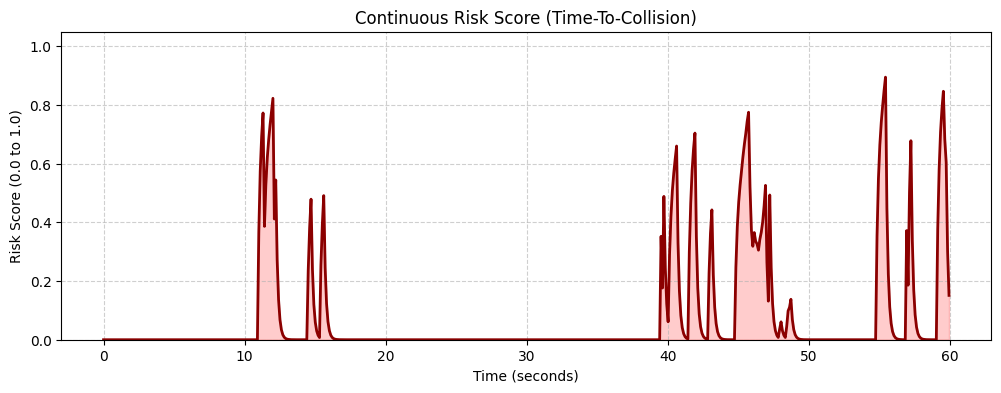

In [24]:
import os
import cv2
import matplotlib.pyplot as plt
import importlib 
import solution 

# Force Python to load your latest changes!
importlib.reload(solution)

# Find sample_02
video_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'sample_02' in filename and filename.endswith('.mp4'):
            video_path = os.path.join(dirname, filename)
            break
    if video_path:
        break

if video_path:
    print(f"Evaluating Risk Score on {video_path}...")
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Initialize your class
    estimator = solution.RiskEstimator()
    estimator.reset({})
    
    times = []
    risks = []
    
    frame_idx = 0
    # Process max 60 seconds to save time, evaluating every 3rd frame
    max_frames = int(fps * 60)
    
    while cap.isOpened() and frame_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_idx % 3 == 0:
            t_sec = frame_idx / fps
            # Step the estimator
            risk = estimator.step(frame, t_sec)
            
            times.append(t_sec)
            risks.append(risk)
            
        frame_idx += 1

    cap.release()
    print("Done! Plotting graph...")
    
    # Plot the results
    plt.figure(figsize=(12, 4))
    plt.plot(times, risks, color='darkred', linewidth=2)
    plt.fill_between(times, risks, color='red', alpha=0.2)
    plt.title("Continuous Risk Score (Time-To-Collision)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Risk Score (0.0 to 1.0)")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Error: Could not find sample_02.")